# Assignment 3: Linear Models

**Q1.** Please answer the following questions in your own words.

1. What makes a model "linear"? "Linear" in what?

A model is called linear when its output depends on the inputs in a simple, proportional way. Changing an input will change the output predictably, usually by multiplying the input by a constant and adding things together. Linear just means the relationship between input and output is straightforward, without powers, products of inputs, or other complicated math.

2. How do you interpret the coefficient for a dummy/one-hot-encoded variable? (Hint: how do you handle the intercept of the model?)

For these variables, the coefficient shows how much the output changes when that category is present compared to the baseline category. The intercept usually represents the output for the baseline category (the one that was left out when creating the dummies). So if the dummy is 1, you add its coefficient to the intercept to get the predicted value for that category.

3. Can linear regression be used for classification? Explain why, or why not.

Linear regression isn’t meant for classification because it predicts continuous numbers, not categories. If you try to use it for something like yes/no, it can give values less than 0 or greater than 1, which don’t make sense as probabilities. You need a model like logistic regression that’s designed to predict categories and keeps the output in a valid range.

4. What are signs that your linear model is over-fitting?

A linear model is overfitting if it does really well on the training data but poorly on new or test data. Other signs include having too many variables compared to the amount of data, very large or unstable coefficients, or the model picking up tiny patterns that don’t make sense in real life. It’s essentially memorizing noise instead of learning the true relationship.

5. Clearly explain multi-colinearity using the two-stage least squares technique.

Multicollinearity happens when two or more input variables are highly correlated, meaning they move together. This makes it hard for a linear model to figure out how much each variable really affects the output because the model can’t tell their effects apart.

Two-stage least squares is a way to deal with this. In the first stage, you predict the problematic variable using other variables that aren’t correlated with the error. In the second stage, you use that predicted version instead of the original variable to estimate the main model. This helps separate the effects and gives more reliable coefficients.

6. How can you incorporate nonlinear relationships between your target/response/dependent/outcome variable $y$ and your features/control/response/independent variables $x$ into your analysis?

You can handle nonlinear relationships by transforming your features or adding new ones that capture the curve. For example, you can square a variable, take its square root, or use logarithms. Another way is to add interaction terms (multiplying variables together) or use piecewise or polynomial terms. You can also use models designed for nonlinear patterns, like decision trees or neural networks, instead of just linear regression.


7. What is the interpretation of the slope coefficient in a linear regression?

The slope coefficient shows how much the predicted outcome changes when that input increases by one unit, assuming all other inputs stay the same. For example, if the slope is 2, then increasing the input by 1 would increase the predicted output by 2. It measures the strength and direction of the relationship between that variable and the outcome.

8. Compare the train/test split and $k$-fold cross validation.

A train/test split divides your data once into a training set to fit the model and a test set to check how well it works. It’s simple but can give unstable results if the split isn’t representative.

K-fold cross-validation splits the data into k parts and trains the model k times, each time using a different part as the test set and the rest for training. This gives a more reliable estimate of performance because every data point gets tested, not just a single split.

9. How is the $k$ in $k$-fold cross validation typically selected?

The k in k-fold cross-validation is usually chosen based on a balance between bias and computation. Common choices are 5 or 10 because they give a good estimate of model performance without being too slow. A higher k (like using leave-one-out) can give more accurate results but takes much longer to compute.


**Q2.** Load `./data/Q1_clean.csv`. The data include

- `Price` per night
- `Review Scores Rating`: The average rating for the property
- `Neighbourhood`: The bourough of NYC. Note the space, or rename the variable.

1. Compute the average prices and scores by `Neighbourhood`; which bourough is the most expensive on average? Create a kernel density plot of price and log price, grouping by `Neighbourhood`.
2. Regress price on `Neighbourhood` by creating the appropriate dummy/one-hot-encoded variables (Are you dropping the first category, or the intercept of the regresssion?). Compare the coefficients in the regression to the table from part 1 (the answer depends on how you handled the dummy variable trap). How are the conditional group means and the estimated coefficients related?
3. Regress price on `Review Scores Rating` and a constant/intercept. Interpret the slope coefficient clearly in words.
4. Regress price on both `Neighbourhood` and `Review Scores Rating`. How does the slope coefficient on `Review Scores Rating` change? How do the neighborhood averages change?
5. Here is a puzzle: Regress price on a constant, and a separate slope coefficient for each neighborhood for `Review Scores Rating`. Are the slopes similar across neighborhoods, or not?
6. Use cross validation to evaluate the models from parts 4, 5, and 6.

In [20]:
# imports 

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import seaborn as sns
import statsmodels.api as sm
from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error



                    Price  ReviewScoresRating
Neighbourhood                                
Bronx           75.276498           91.654378
Brooklyn       127.747378           92.363497
Manhattan      183.664286           91.801496
Queens          96.857233           91.549057
Staten Island  146.166667           90.843750
Manhattan


<>:1: SyntaxWarning: invalid escape sequence '\Q'
<>:1: SyntaxWarning: invalid escape sequence '\Q'
C:\Users\ayanr\AppData\Local\Temp\ipykernel_16612\3164198968.py:1: SyntaxWarning: invalid escape sequence '\Q'
  df = pd.read_csv('data\Q1_clean.csv') # load file


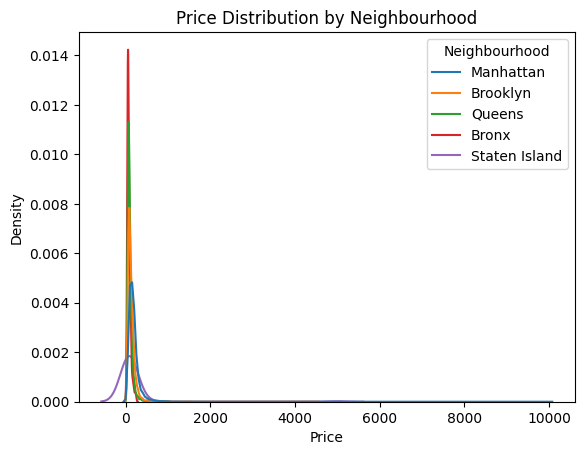

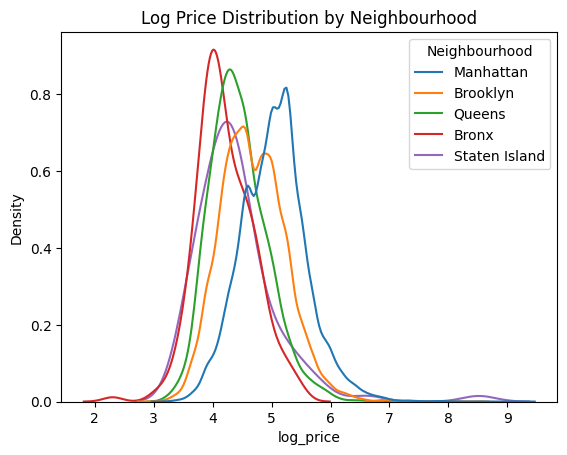

In [21]:
df = pd.read_csv('data\Q1_clean.csv') # load file
df = df.rename(columns={'Review Scores Rating': 'ReviewScoresRating'})
df = df.dropna(subset=['Price', 'ReviewScoresRating', 'Neighbourhood']) # drop missing

#2.1 : compute average prices and scores
group_means = df.groupby('Neighbourhood')[['Price', 'ReviewScoresRating']].mean()
print(group_means)

# most expensive bourough is manhattan
print(group_means['Price'].idxmax())

# kernel density plots: 

# price
sns.kdeplot(data=df, x='Price', hue='Neighbourhood', common_norm=False)
plt.title("Price Distribution by Neighbourhood")
plt.show()

# log price (normalized)
df['log_price'] = np.log(df['Price'])

sns.kdeplot(data=df, x='log_price', hue='Neighbourhood', common_norm=False)
plt.title("Log Price Distribution by Neighbourhood")
plt.show()

In [ ]:
#2.2 regress price on neighborhood

dummies = pd.get_dummies(df['Neighbourhood'], drop_first=True).astype(int)  # we are dropping the first

X = sm.add_constant(dummies)   # includes intercept
y = df['Price']

model = sm.OLS(y, X).fit()
print(model.summary())

# when we compare prices to the regression in the table from part 1, can see that the regression coefficients are the differences between the group means

                            OLS Regression Results                            
Dep. Variable:                  Price   R-squared:                       0.046
Model:                            OLS   Adj. R-squared:                  0.046
Method:                 Least Squares   F-statistic:                     268.9
Date:                Wed, 18 Mar 2026   Prob (F-statistic):          4.43e-226
Time:                        01:24:30   Log-Likelihood:            -1.4174e+05
No. Observations:               22153   AIC:                         2.835e+05
Df Residuals:                   22148   BIC:                         2.835e+05
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
const            75.2765      9.868      7.628

In [32]:
# 2.3 regress price on reviewscore

X = sm.add_constant(df['ReviewScoresRating'])
y = df['Price']

model = sm.OLS(y, X).fit()
print(model.summary())

# slope intercept = 1.0208, meaning that for a 1.0208 increase in the nightly price, it will average a 1 point increase in the review score

                            OLS Regression Results                            
Dep. Variable:                  Price   R-squared:                       0.004
Model:                            OLS   Adj. R-squared:                  0.004
Method:                 Least Squares   F-statistic:                     81.92
Date:                Wed, 18 Mar 2026   Prob (F-statistic):           1.53e-19
Time:                        01:26:24   Log-Likelihood:            -1.4222e+05
No. Observations:               22153   AIC:                         2.844e+05
Df Residuals:                   22151   BIC:                         2.845e+05
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
const                 60.8784     10

In [ ]:
# 2.4 regress price on both neighbourhood and review scores rating

X = pd.concat([df['ReviewScoresRating'], dummies], axis=1)
X = sm.add_constant(X)

model = sm.OLS(df['Price'], X).fit()
print(model.summary())

# review score coeff. stayed around the same, very slight increase (1.02 -> 1.08)
# relationship between review score and price not strong confounded w/ neighborhood

# neighborhood averages cost more than the baseline (manhattan costs ~$108 more, brooklyn ~$52 more, queens ~$22 more, staten island ~$72 more)

                            OLS Regression Results                            
Dep. Variable:                  Price   R-squared:                       0.050
Model:                            OLS   Adj. R-squared:                  0.050
Method:                 Least Squares   F-statistic:                     235.3
Date:                Wed, 18 Mar 2026   Prob (F-statistic):          1.21e-245
Time:                        01:31:36   Log-Likelihood:            -1.4169e+05
No. Observations:               22153   AIC:                         2.834e+05
Df Residuals:                   22147   BIC:                         2.834e+05
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
const                -23.8126     14

In [ ]:
# 2.5 
for col in dummies.columns:
    df[f'{col}_x_score'] = dummies[col] * df['ReviewScoresRating']

X = pd.concat([df['ReviewScoresRating'], dummies,
               df[[f'{col}_x_score' for col in dummies.columns]]], axis=1)

X = sm.add_constant(X)

model = sm.OLS(df['Price'], X).fit()
print(model.summary())

# the slopes across the neighborhoods are mostly similar with some variation, except for staten island which is an outlier

                            OLS Regression Results                            
Dep. Variable:                  Price   R-squared:                       0.068
Model:                            OLS   Adj. R-squared:                  0.067
Method:                 Least Squares   F-statistic:                     178.4
Date:                Wed, 18 Mar 2026   Prob (F-statistic):               0.00
Time:                        01:34:15   Log-Likelihood:            -1.4149e+05
No. Observations:               22153   AIC:                         2.830e+05
Df Residuals:                   22143   BIC:                         2.831e+05
Df Model:                           9                                         
Covariance Type:            nonrobust                                         
                            coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------
const                    22.63

In [41]:
# 2.6 cross validation

def cross_val_mse(X, y, k=5):
    kf = KFold(n_splits=k, shuffle=True, random_state=1)
    mses = []

    for train_idx, test_idx in kf.split(X):
        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

        model = sm.OLS(y_train, X_train).fit()
        preds = model.predict(X_test)

        mses.append(mean_squared_error(y_test, preds))

    return np.mean(mses)

X4 = sm.add_constant(pd.concat([df['ReviewScoresRating'], dummies], axis=1))
mse4 = cross_val_mse(X4, df['Price'])

interaction_cols = [f'{col}_x_score' for col in dummies.columns]

X5 = sm.add_constant(pd.concat([
    df['ReviewScoresRating'], dummies, df[interaction_cols]
], axis=1))

mse5 = cross_val_mse(X5, df['Price'])


**Q3.** This question is a case study for linear models. The data are about car prices. In particular, they include:

  - `Price`: In Indian rupees
  - `Seating_Capacity`: Number of seats
  - `Body_Type`: crossover, hatchback, muv, sedan, suv
  - `Make_Year`: The year the car was made

  1. Load `cars_hw.csv`. Summarize the `Price` variable and create a kernel density plot. Use `.groupby()` and `.describe()` to summarize prices by `Body_Type`. Make a grouped kernel density plot by `Body_Type`. Which car types are the most expensive? Which have the most variance?

<>:5: SyntaxWarning: "\c" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\c"? A raw string is also an option.
<>:5: SyntaxWarning: "\c" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\c"? A raw string is also an option.
C:\Users\emili\AppData\Local\Temp\ipykernel_32416\3222879534.py:5: SyntaxWarning: "\c" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\c"? A raw string is also an option.
  df3 = pd.read_csv('data\cars_hw.csv')


count    9.760000e+02
mean     7.410195e+05
std      3.673234e+05
min      1.880000e+05
25%      4.757500e+05
50%      6.665000e+05
75%      8.830000e+05
max      2.941000e+06
Name: Price, dtype: float64


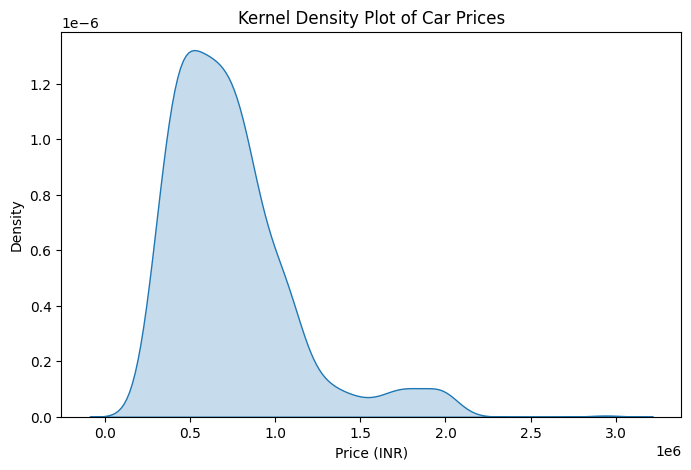

           count          mean            std       min       25%        50%  \
Body_Type                                                                      
crossover   21.0  7.050952e+05   72849.780207  608000.0  638000.0   706000.0   
hatchback  484.0  5.339773e+05  173086.729837  188000.0  401750.0   509000.0   
muv         38.0  6.264211e+05  184093.488526  328000.0  489750.0   621500.0   
sedan      227.0  8.097841e+05  286736.770092  368000.0  598000.0   772000.0   
suv        206.0  1.176495e+06  417479.028217  559000.0  860000.0  1065000.0   

                 75%        max  
Body_Type                        
crossover   749000.0   883000.0  
hatchback   661000.0  1107000.0  
muv         738500.0  1091000.0  
sedan       968500.0  2941000.0  
suv        1491250.0  2100000.0  


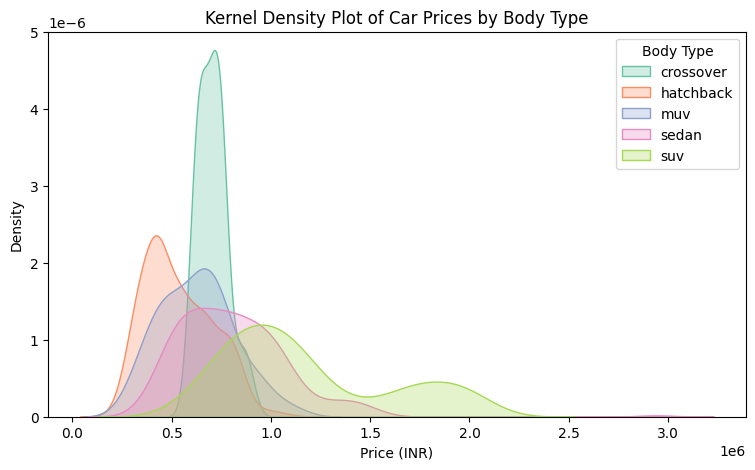

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df3 = pd.read_csv('data\cars_hw.csv')

# summarize Price
print(df3['Price'].describe())

# kernel density plot of Price
plt.figure(figsize=(8, 5))
sns.kdeplot(df3['Price'], fill=True)
plt.title('Kernel Density Plot of Car Prices')
plt.xlabel('Price (INR)')
plt.ylabel('Density')
plt.show()

# summarize Price by Body_Type
print(df3.groupby('Body_Type')['Price'].describe())

# grouped kernel density plot by Body_Type
palette = sns.color_palette("Set2", n_colors=df3['Body_Type'].nunique())

plt.figure(figsize=(9, 5))
for (body_type, group), color in zip(df3.groupby('Body_Type'), palette):
    sns.kdeplot(group['Price'], label=body_type, fill=True, alpha=0.3, color=color)

plt.title('Kernel Density Plot of Car Prices by Body Type')
plt.xlabel('Price (INR)')
plt.ylabel('Density')
plt.legend(title='Body Type')
plt.show()


SUVs are the most expensive (₹1,176,495 mean price) and they also have the most variance (417479.028217 std).

  2. Regress `Price` on `Seating_Capacity`. What's the slope coefficient? Interpret it. Now treat `Seating_Capacity` as a one hot encoded variable, and regress price on it as if it is categorical. Are the differences in price roughly linear in the number of seats?

In [9]:
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import OneHotEncoder

# regression 1: Seating_Capacity as numeric
X1 = df3[['Seating_Capacity']]
y = df3['Price']

model1 = LinearRegression()
model1.fit(X1, y)

print("Numeric Seating_Capacity")
print(f"Slope:     {model1.coef_[0]:,.2f}")
print(f"Intercept: {model1.intercept_:,.2f}")
print(f"R²:        {model1.score(X1, y):.4f}")

# regression 2: Seating_Capacity as one-hot encoded
ohe = OneHotEncoder(drop='first', sparse_output=False)
X2 = ohe.fit_transform(df3[['Seating_Capacity']])

model2 = LinearRegression()
model2.fit(X2, y)

print("\nCategorical Seating_Capacity (One-Hot Encoded)")
categories = ohe.categories_[0][1:]  # drop first matches drop='first'
for cat, coef in zip(categories, model2.coef_):
    print(f"  Seating_{cat} vs baseline: {coef:,.2f}")
print(f"Intercept (baseline mean): {model2.intercept_:,.2f}")
print(f"R²: {model2.score(X2, y):.4f}")


Numeric Seating_Capacity
Slope:     59,268.00
Intercept: 439,032.01
R²:        0.0052

Categorical Seating_Capacity (One-Hot Encoded)
  Seating_5 vs baseline: 546,483.87
  Seating_6 vs baseline: 1,456,000.00
  Seating_7 vs baseline: 735,948.72
  Seating_8 vs baseline: 271,800.00
Intercept (baseline mean): 188,000.00
R²: 0.0218


The slope is ₹59,268. This means that for each additional seat, a car's price is predicted to increase by ₹59,268 on average. However, given the very low R² of 0.0052, seating capacity explains almost none of the variation in price, so this relationship is statistically weak and not practically meaningful on its own.

The differences are not roughly linear. If the relationship were linear, each additional seat would add roughly the same amount to the price (~₹59,268 as the numeric model assumes). But the categorical coefficients show us that:

* The 6-seat category commands a huge premium (₹14.56L above the 4-seat baseline)
* 7 and 8-seat cars are actually cheaper than 6-seat cars, despite having more seats
* This non-monotonic pattern (prices rising then falling as seats increase)  is not linear

The likely explanation is that seat count is a proxy for vehicle type rather than a direct driver of price. 6-seat cars tend to be a niche luxury/MPV segment, while 7-8 seat cars include more budget-friendly family vehicles.



  3. Use `Make_Year` to create a new variable that corresponds to the age of the vehicle. Use 10-fold cross validation to determine the optimal number of powers of `Age` to include in a regression of `Price` on `Age`. 

Optimal degree: 9
  Degree 1: MSE = 100,295,370,079.46
  Degree 2: MSE = 100,814,620,596.42
  Degree 3: MSE = 100,380,163,091.92
  Degree 4: MSE = 100,474,431,121.12
  Degree 5: MSE = 100,131,346,196.07
  Degree 6: MSE = 100,347,765,586.89
  Degree 7: MSE = 99,809,273,154.25
  Degree 8: MSE = 99,350,293,056.90
  Degree 9: MSE = 99,043,841,484.93
  Degree 10: MSE = 99,143,659,816.76


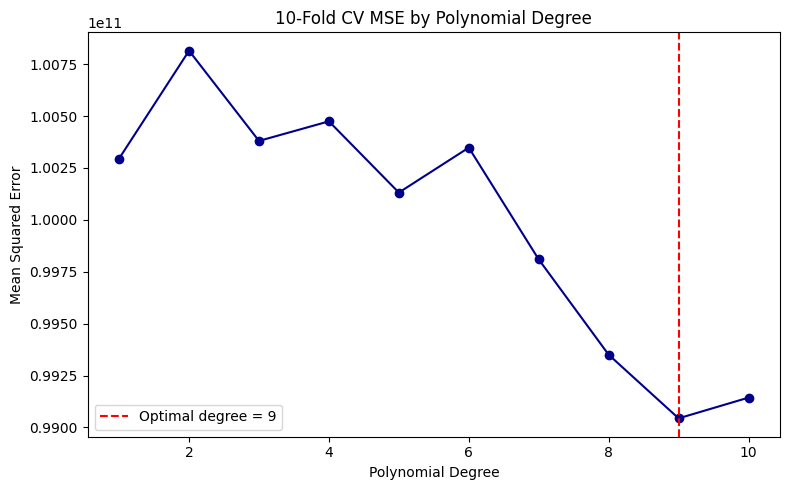

In [22]:
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import Pipeline
import numpy as np

df3['Age'] = 2023 - df3['Make_Year']

X = df3[['Age']]
y = df3['Price']

# test polynomial degrees 1 through 10
degrees = range(1, 11)
cv_scores = []

for degree in degrees:
    pipeline = Pipeline([
        ('poly', PolynomialFeatures(degree=degree, include_bias=False)),
        ('model', LinearRegression())
    ])
    scores = cross_val_score(pipeline, X, y, cv=10, scoring='neg_mean_squared_error')
    cv_scores.append(-scores.mean())

# find optimal degree
optimal_degree = degrees[np.argmin(cv_scores)]
print(f"Optimal degree: {optimal_degree}")
for d, score in zip(degrees, cv_scores):
    print(f"  Degree {d}: MSE = {score:,.2f}")

# plot CV scores
plt.figure(figsize=(8, 5))
plt.plot(degrees, cv_scores, marker='o', color='darkblue')
plt.axvline(optimal_degree, color='red', linestyle='--', label=f'Optimal degree = {optimal_degree}')
plt.title('10-Fold CV MSE by Polynomial Degree')
plt.xlabel('Polynomial Degree')
plt.ylabel('Mean Squared Error')
plt.legend()
plt.tight_layout()
plt.show()

  4. Plot `Price` against `Age`, and then model-predicted price against `Age`. Does the model accurately fit the patterns in the data?

Optimal degree: 9


c:\Users\emili\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(


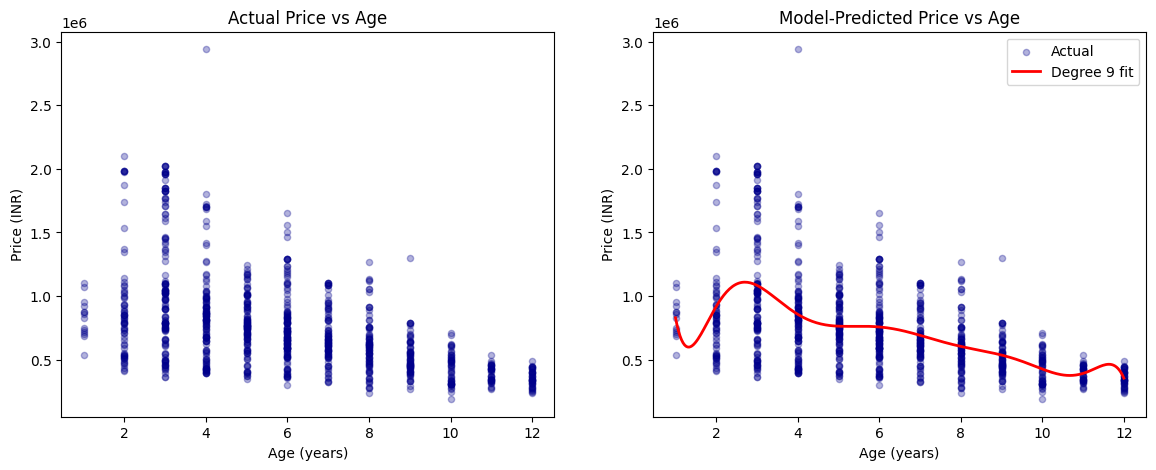

In [23]:
X = df3[['Age']]
y = df3['Price']

degrees = range(1, 11)
cv_scores = []

for degree in degrees:
    pipeline = Pipeline([
        ('poly', PolynomialFeatures(degree=degree, include_bias=False)),
        ('model', LinearRegression())
    ])
    scores = cross_val_score(pipeline, X, y, cv=10, scoring='neg_mean_squared_error')
    cv_scores.append(-scores.mean())

optimal_degree = degrees[np.argmin(cv_scores)]
print(f"Optimal degree: {optimal_degree}")

optimal_pipeline = Pipeline([
    ('poly', PolynomialFeatures(degree=optimal_degree, include_bias=False)),
    ('model', LinearRegression())
])
optimal_pipeline.fit(X, y)

# smooth age range for prediction line
age_range = np.linspace(df3['Age'].min(), df3['Age'].max(), 300).reshape(-1, 1)
predicted_prices = optimal_pipeline.predict(age_range)


fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# actual price vs age
axes[0].scatter(df3['Age'], df3['Price'], alpha=0.3, color='darkblue', s=20)
axes[0].set_title('Actual Price vs Age')
axes[0].set_xlabel('Age (years)')
axes[0].set_ylabel('Price (INR)')

# predicted price vs age on top of actual ^^
axes[1].scatter(df3['Age'], df3['Price'], alpha=0.3, color='darkblue', s=20, label='Actual')
axes[1].plot(age_range, predicted_prices, color='red', linewidth=2, label=f'Degree {optimal_degree} fit')
axes[1].set_title('Model-Predicted Price vs Age')
axes[1].set_xlabel('Age (years)')
axes[1].set_ylabel('Price (INR)')
axes[1].legend()

plt.show()


The model captures the overall negative relationship between Age and Price, indicating that older cars tend to have lower prices. However, the fitted polynomial curve shows several fluctuations that do not reflect the expected smooth depreciation of car values as age increases. This suggests that the degree-9 polynomial may be overfitting the data, fitting noise rather than the true underlying trend.

**Q4.** This question refers to the `heart_hw.csv` data. It contains three variables:

  - `y`: Whether the individual survived for three years, coded 0 for death and 1 for survival
  - `age`: Patient's age
  - `transplant`: labelled `control` for not receiving a transplant and labelled `treatment` for receiving a transplant

Since a heart transplant is a dangerous operation and even people who successfully get heart transplants might suffer later complications, we want to look at whether a group of transplant recipients tends to survive longer than a comparison group who does not get the procedure.

1. Compute (a) the proportion of people who survive in the control group and (b) in the treatment group. Compute (b) minus (a) as the average treatment effect (ATE). What is the ATE on three-year survival for heart transplant interventions?
2. Regress `y` on `transplant` using a linear model with a constant. Compare the intercept and transplant coefficient to the numbers you computed in part 1. 
3. Regress `y` on transplant and age. How does the coefficient on transplant change when you control for age?What do the intercept and slope represent? Plot the predicted probability of survival by age, and add a dashed horizontal line for the ATE from part 1. For what ages is the ATE over- or under-estimating the impact of a transplant?
4. Now, include `transplant`, `age`, and `transplant * age` as controls. Repeat your analysis from part 3. How does allowing age and transplant to interact change your predictions? What pattern do you notice?
5. Use 10-fold cross validation to evaluate the predictive accuracy of these models. 
6. Imagine this model is used to prioritize transplant access. What are your concerns about model construction and deployment?
